# Huấn luyện Model 2 — Hybrid Transformer-CNN (ASL Alphabet)

Notebook này chạy đúng pipeline đã thiết kế theo bài báo:
> Aly, M. & Fathi, I. S. "Recognizing American Sign Language gestures efficiently and accurately using a hybrid transformer model." *Scientific Reports* 15, 20253 (2025).

**6 file code BẮT BUỘC phải có trong project** (không cần `normalize_landmarks.py` hay `convert_to_yolo_format.py` — 2 file đó thuộc Model 1 và Model 3):

```
configs/config.py
src/utils/dataset_split.py
src/preprocessing/extract_landmarks.py
src/preprocessing/hybrid_transforms.py
src/preprocessing/prepare_hybrid_dataset.py
src/models/model2_hybrid_transformer_cnn/dataset.py
src/models/model2_hybrid_transformer_cnn/model.py
src/models/model2_hybrid_transformer_cnn/train.py
```

Notebook này giả định bạn chạy trên **Google Colab**. Nếu chạy máy cá nhân (Jupyter local), bỏ qua các cell có `# COLAB ONLY`.


## Bước 1 — Cài đặt thư viện

⚠️ **Bắt buộc pin đúng 2 phiên bản dưới đây** — đã test tương thích với nhau:
- `mediapipe==0.10.14` (bản mới hơn đã bỏ API `solutions.hands`)
- `tensorflow-cpu==2.16.1` (bản mới hơn xung đột `protobuf` với mediapipe)


In [2]:
import sys
# Gỡ cài đặt các phiên bản tensorflow và keras hiện có để tránh xung đột
# !pip uninstall tensorflow -y
# !pip uninstall keras -y

# Cài đặt lại các thư viện cần thiết, bao gồm TensorFlow đầy đủ cho GPU
# `tensorflow` sẽ tự động chọn phiên bản GPU nếu runtime được cấu hình
!pip install -q mediapipe==0.10.30 tensorflow opencv-python-headless pandas scikit-learn tqdm
print("Đã cài xong. Cần Runtime > Restart runtime NGAY BÂY GIỜ để đảm bảo TensorFlow hoạt động đúng.")


Đã cài xong. Cần Runtime > Restart runtime NGAY BÂY GIỜ để đảm bảo TensorFlow hoạt động đúng.


In [4]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found GPU(s): {gpus}")
    print("TensorFlow đang sử dụng GPU.")
else:
    print("Không tìm thấy GPU. TensorFlow đang sử dụng CPU.")
    print("Để sử dụng GPU, hãy vào Runtime > Change runtime type và chọn T4 GPU.")

Found GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow đang sử dụng GPU.


## Bước 2 — Tạo cấu trúc thư mục project

Chạy cell dưới để tạo đúng cấu trúc thư mục. Sau đó **upload 6 file .py** (đã liệt kê ở trên) vào đúng vị trí — dùng cell upload ở bước tiếp theo.


In [5]:
from google.colab import drive, files
import os

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition"  # đổi lại nếu chạy local

dirs = [
    "configs",
    "src/preprocessing",
    "src/models/model2_hybrid_transformer_cnn",
    "src/utils",
    "data/raw/asl_alphabet",
    "data/hybrid_manifest",
    "checkpoints",
]
for d in dirs:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

# File __init__.py để các thư mục hoạt động như package Python
for pkg_dir in ["configs", "src", "src/preprocessing", "src/models",
                "src/models/model2_hybrid_transformer_cnn", "src/utils"]:
    open(os.path.join(PROJECT_ROOT, pkg_dir, "__init__.py"), "a").close()

os.chdir(PROJECT_ROOT)
print("Thư mục làm việc hiện tại:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thư mục làm việc hiện tại: /content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition


## Bước 3 — Upload 6 file code bắt buộc

Chạy cell dưới, chọn **CÙNG LÚC cả 6 file .py** đã liệt kê ở đầu notebook (giữ nguyên tên file gốc — script sẽ tự nhận diện và copy vào đúng thư mục dựa theo tên file).

> Nếu chạy Jupyter local (không phải Colab), bỏ qua cell `files.upload()` này — copy 6 file thủ công vào đúng cấu trúc thư mục ở Bước 2 rồi chạy tiếp từ Bước 4.


In [3]:
# COLAB ONLY
import shutil

uploaded = files.upload()  # chọn 6 file .py cùng lúc trong hộp thoại hiện ra

FILE_DESTINATION = {
    "config.py": "configs/config.py",
    "dataset_split.py": "src/utils/dataset_split.py",
    "extract_landmarks.py": "src/preprocessing/extract_landmarks.py",
    "hybrid_transforms.py": "src/preprocessing/hybrid_transforms.py",
    "prepare_hybrid_dataset.py": "src/preprocessing/prepare_hybrid_dataset.py",
    "dataset.py": "src/models/model2_hybrid_transformer_cnn/dataset.py",
    "model.py": "src/models/model2_hybrid_transformer_cnn/model.py",
    "train.py": "src/models/model2_hybrid_transformer_cnn/train.py",
}

for filename in uploaded:
    if filename in FILE_DESTINATION:
        dest = os.path.join(PROJECT_ROOT, FILE_DESTINATION[filename])
        shutil.move(filename, dest)
        print(f"Đã copy {filename} -> {dest}")
    else:
        print(f"[CẢNH BÁO] Không nhận diện được file '{filename}', bỏ qua.")


In [ ]:
# Kiểm tra lại cấu trúc file đã đủ chưa

required_files = list(FILE_DESTINATION.values())
missing = [f for f in required_files if not os.path.exists(os.path.join(PROJECT_ROOT, f))]

if missing:
    print("❌ THIẾU các file sau, hãy upload lại:")
    for f in missing:
        print("  -", f)
else:
    print("✅ Đã đủ 6 file bắt buộc, sẵn sàng chạy tiếp.")


✅ Đã đủ 6 file bắt buộc, sẵn sàng chạy tiếp.


## Bước 4 — Chuẩn bị dataset ASL Alphabet

Cách nhanh nhất: dùng Kaggle API. Cần file `kaggle.json` (token API cá nhân, tải từ trang Kaggle > Account > Create New API Token).


In [ ]:
# # COLAB ONLY - Tải dataset từ Kaggle
# # 1. Upload file kaggle.json khi được hỏi
# from google.colab import files
# uploaded = files.upload()  # chọn file kaggle.json

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !pip install -q kaggle
# # !kaggle datasets download -d grassknoted/asl-alphabet -p /content/asl_download
# !unzip -q /content/asl_download/asl-alphabet.zip -d /content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition/data/raw/asl_alphabet


Saving kaggle (1).json to kaggle (1) (3).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
replace /content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition/data/raw/asl_alphabet/asl_alphabet_test/asl_alphabet_test/A_test.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# # Copy ảnh vào đúng cấu trúc data/raw/asl_alphabet/<label>/*.jpg
# import shutil, glob

# # Cấu trúc gốc của bộ Kaggle: asl_alphabet_train/asl_alphabet_train/<label>/*.jpg
# src_root = glob.glob("/content/asl_download/**/asl_alphabet_train", recursive=True)
# assert src_root, "Không tìm thấy thư mục asl_alphabet_train — kiểm tra lại đường dẫn giải nén."
# src_root = src_root[0]

# dst_root = os.path.join(PROJECT_ROOT, "data/raw/asl_alphabet")
# for label_dir in os.listdir(src_root):
#     shutil.move(os.path.join(src_root, label_dir), os.path.join(dst_root, label_dir))

# print("Số lớp đã copy:", len(os.listdir(dst_root)))
# print("Danh sách lớp:", sorted(os.listdir(dst_root)))


Error: Destination path '/content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition/data/raw/asl_alphabet/asl_alphabet_train/asl_alphabet_train' already exists

> **Nếu không dùng Kaggle API**: upload ảnh thủ công vào `data/raw/asl_alphabet/<label>/` (mỗi thư mục con là 1 nhãn: A, B, C, ..., del, nothing, space) qua giao diện Colab (Files > kéo thả) hoặc mount Google Drive.

## Bước 5 — Tạo manifest + chia train/val/test


In [6]:
import sys
sys.path.insert(0, PROJECT_ROOT)  # để import được configs.config, src.*

from configs.config import PreprocessConfig
from src.preprocessing.prepare_hybrid_dataset import build_manifest
from src.utils.dataset_split import split_dataset

cfg = PreprocessConfig()

# Nếu bộ dữ liệu của bạn không đủ 29 lớp (ví dụ chỉ thu vài lớp để test),
# sửa lại danh sách nhãn ở đây cho khớp:
# cfg.hybrid.hybrid_class_labels = ["A", "B", "C"]
# print(cfg.raw_images_dir)
# df = build_manifest("/content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition/data/raw/asl-alphabet/asl_alphabet_train", cfg.hybrid.hybrid_class_labels)
# print("Tổng số ảnh:", len(df))
# print(df["label"].value_counts())

# train_df, val_df, test_df = split_dataset(df, cfg.split)
# os.makedirs(cfg.hybrid_manifest_dir, exist_ok=True)
# train_df.to_csv(cfg.hybrid_train_manifest, index=False)
# val_df.to_csv(cfg.hybrid_val_manifest, index=False)
# test_df.to_csv(cfg.hybrid_test_manifest, index=False)

# print(f"Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}")


In [8]:
# !pip uninstall mediapipe -y
# !pip install mediapipe==0.10.21
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## Bước 6 — Kiểm tra nhanh 1 batch dữ liệu (dual-path)

Xem thử ảnh nhánh Primary (ảnh toàn cục) và Auxiliary (vùng tay đã tăng cường) có ra đúng như kỳ vọng không, trước khi train tốn thời gian.


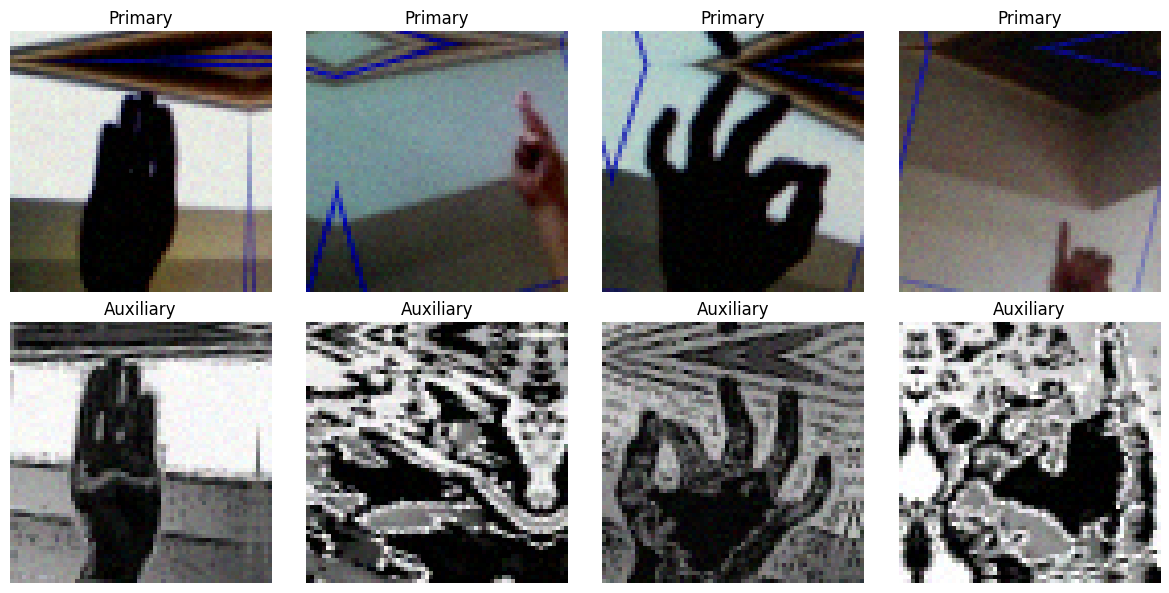

In [7]:
import matplotlib.pyplot as plt
from src.models.model2_hybrid_transformer_cnn.dataset import HybridASLDataset

class_labels = cfg.hybrid.hybrid_class_labels
preview_ds = HybridASLDataset(cfg.hybrid_train_manifest, cfg, class_labels, training=True)
(primary_batch, auxiliary_batch), label_batch = preview_ds[0]
preview_ds.close()

n_show = min(4, len(primary_batch))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(primary_batch[i]); axes[0, i].set_title("Primary"); axes[0, i].axis("off")
    axes[1, i].imshow(auxiliary_batch[i]); axes[1, i].set_title("Auxiliary"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## Bước 7 — Xây dựng model, xem kiến trúc


In [8]:
from src.models.model2_hybrid_transformer_cnn.model import build_hybrid_model, compile_model

num_classes = len(class_labels)

train_ds = HybridASLDataset(cfg.hybrid_train_manifest, cfg, class_labels, training=True)
val_ds = HybridASLDataset(cfg.hybrid_val_manifest, cfg, class_labels, training=False)

model = build_hybrid_model(cfg.hybrid, num_classes)
model = compile_model(model, cfg.hybrid, steps_per_epoch=len(train_ds))
model.summary()


Model: "Hybrid_Transformer_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ primary_input       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_input     │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_conv1       │ (None, 64, 64,    │        896 │ primary_input[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_conv1     │ (None, 64, 64,    │        896 │ auxiliary_input[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_pool1       │ (None, 32, 32,    │          0 │ primary_conv1[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_pool1     │ (None, 32, 32,    │          0 │ auxiliary_conv1[… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_conv2       │ (None, 32, 32,    │     18,496 │ primary_pool1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_conv2     │ (None, 32, 32,    │     18,496 │ auxiliary_pool1[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_pool2       │ (None, 16, 16,    │          0 │ primary_conv2[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_pool2     │ (None, 16, 16,    │          0 │ auxiliary_conv2[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_patch_embed │ (None, 4, 4, 128) │    131,200 │ primary_pool2[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_patch_em… │ (None, 4, 4, 128) │    131,200 │ auxiliary_pool2[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_flatten_pa… │ (None, 16, 128)   │          0 │ primary_patch_em… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auxiliary_flatten_… │ (None, 16, 128)   │          0 │ auxiliary_patch_… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 128)   │          0 │ primary_flatten_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 128)   │          0 │ auxiliary_flatte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_transforme… │ (None, 16, 128)   │    132,480 │ add[0][0]         │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 851,357 (3.25 MB)

 Trainable params: 851,357 (3.25 MB)

 Non-trainable params: 0 (0.00 B)

## Bước 8 — Huấn luyện

Bài báo train 60 epoch. Trên Colab GPU miễn phí, 1 epoch với ~87.000 ảnh sẽ mất kha khá thời gian — có thể giảm `epochs` để chạy thử trước.


In [ ]:
import tensorflow as tf

cfg.hybrid.epochs = 60          # giảm xuống ví dụ 3-5 nếu chỉ muốn chạy thử nhanh
checkpoint_path = os.path.join(PROJECT_ROOT, cfg.hybrid_checkpoint_path)
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=cfg.hybrid.early_stopping_patience,
                                      restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=cfg.hybrid.epochs,
    callbacks=callbacks,
)

train_ds.close()
val_ds.close()


Epoch 1/60
 10/952 ━━━━━━━━━━━━━━━━━━━━ 13:00:43 50s/step - accuracy: 0.0328 - loss: 3.5354

KeyboardInterrupt: 

## Bước 9 — Đánh giá trên tập test


In [ ]:
test_ds = HybridASLDataset(cfg.hybrid_test_manifest, cfg, class_labels, training=False)
test_loss, test_acc = model.evaluate(test_ds)
test_ds.close()
print(f"Test Accuracy: {test_acc:.4f} — Test Loss: {test_loss:.4f}")


## Ghi chú

- Checkpoint tốt nhất được lưu tại `checkpoints/model2_hybrid_transformer_cnn_best.keras`.
- Để vẽ confusion matrix / precision-recall theo từng lớp, dùng `model.predict()` trên `test_ds` rồi so với nhãn thật (giống Table 4/Fig 7 trong bài báo gốc).
- Model 1 (MLP trên landmark) và Model 3 (YOLOv11n) chạy độc lập, không phụ thuộc vào các file của notebook này — xem roadmap tổng để biết file cần dùng cho từng model.
